# Lab Week 2: Plotting Exercises

In this lab, you need to solve some exercises with matplotlib, a python library for plotting.

<div style="border-bottom: 3px solid black; margin-bottom:5px"></div>
<div style="border-bottom: 3px solid black;"></div>

## 1. Plotting exercises
First, in the code cell below, write code to import the _pyplot_ module from the Matplotlib package in the standard way, then run the code cell.

In [89]:
import numpy as np
import matplotlib.pyplot as plt

If you imported the _pyplot_ module from Matplotlib correctly you should be able to run the code cell below without error.

In [90]:
assert "matplotlib" not in globals(), "You didn't need to import matplotlib itself, just the pyplot submodule."
assert "pyplot" not in globals(), "You didn't import pyplot in the standard way. Do Kernel->Restart and then try again."
assert "plt" in globals(), "You didn't import pyplot in the standard way. Do Kernel->Restart and then try again."
print("Ready!")

Ready!


<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.1 &ndash; Plot a function

**Plot these functions** over the interval $x \in [-5, 5]$:

1. The [sigmoid](https://en.wikipedia.org/wiki/Sigmoid_function) function $\sigma(x) = \frac{1}{1+e^{-x}}$
2. The (leaky) [rectifier](https://en.wikipedia.org/wiki/Rectifier_(neural_networks)) function $f(x) = \max(0, x) + \alpha \min(0, x)$ with slope $\alpha$ for negative inputs

Requirements:
* Use Numpy ndarrays and Numpy functions for your solution, _not_ Python lists.
* Plot both curves in the same plot.
* Use the **plt.[ylim](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.ylim.html)** function to set the y axis range to $[-0.5,3.1]$.
* Use the **plt.[grid](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.grid.html)** function to show a grid.
* Use the **plt.[xlabel](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xlabel.html)** function to set the x-axis label.
* Use the **plt.[legend](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.legend.html)** function to add a legend.
* Use the **plt.[title](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.title.html)** function to add a title.
* Use `negative_slope=0.05`, i.e. $\alpha = 0.05$.

You should be able to reproduce the plot below:

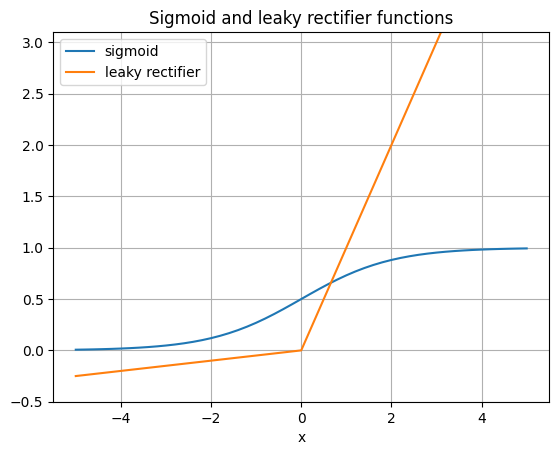

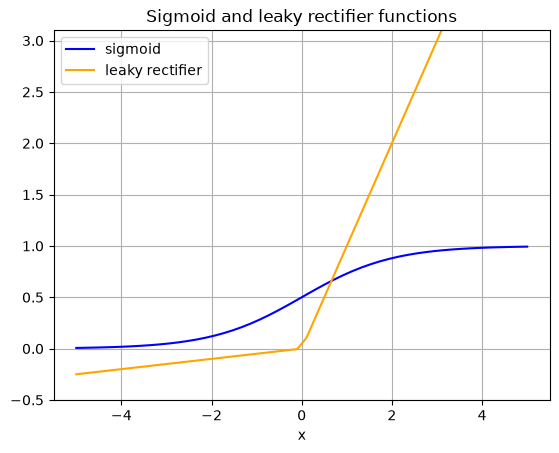

In [ ]:
def sigmoid(x):
    # Your code here. Aim for 1-2 lines.
    return 1/(1 + np.exp(-x))

def leaky_relu(x, negative_slope=0.05):
    # Your code here. Aim for 1-2 lines.
    return np.maximum(0, x) + (negative_slope)*np.minimum(0, x)

# Your code here. Aim for 8-10 lines.
x = np.linspace(-5, 5)
plt.plot(x, sigmoid(x), label='sigmoid', color='blue')
plt.plot(x, leaky_relu(x), label='leaky rectifier', color='orange')
plt.ylim(-0.5, 3.1)
plt.grid()
plt.xlabel("x")
plt.legend()
plt.title("Sigmoid and leaky rectifier functions")
plt.show()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.2 &ndash; Plot accuracy of finite differences

In the previous lab, we defined a function that approximates the derivative of f at any point.

**Run** the code below to re-define this function.

In [92]:
def approx_derivative_of(f, epsilon=1e-6):
    """Returns a new function that approximates the derivative of f at any point.

    Arguments:
    f       -- the function f(x) whose derivative we wish to approximate
    epsilon -- the step size to use for central differencing (default 1e-6)
    """
    return lambda x: (f(x + epsilon) - f(x - epsilon)) / (2*epsilon)

**Plot the accuracy** of the central difference approximation for different values of the step size $\epsilon$. Your plot should show that the finite difference approximation breaks down for values of $\epsilon$ that are too large or too small.

**Run the code cell below** to define functions for $f(x) = x^3$ and its exact first derivative $f'(x) = 3x^2$.

In [93]:
def f(x):
    return x**3

def df_exact(x):
    return 3 * x**2

First, plot the `f` and `f_exact` functions over range $x \in [-1.2, 1.2]$, including title and legend as shown below:


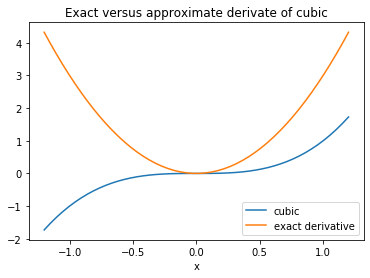

Second, once you've got the above plot, use the `approx_derivative_of(f, epsilon)` function to add three new series to your plot, corresponding to $\epsilon=1$, $\epsilon=10^{-5}$, and $\epsilon=10^{-15}$. Your new plot should look like this:

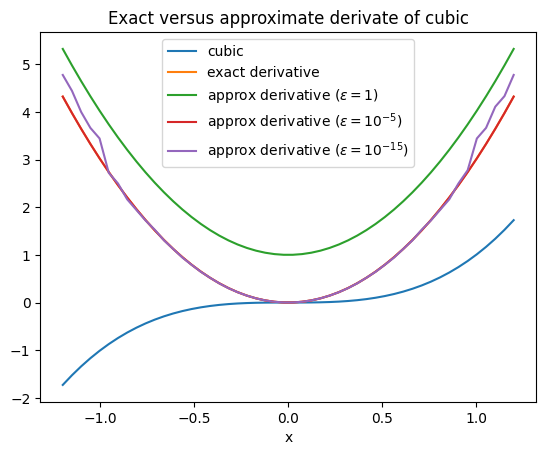

Make greek symbols like $\epsilon$ in a label or a title by using the dollar sign (\$) and superscript (^), such as `"Argument $\beta$ has value $10^{3}$"` would render in the plot as <span style="border: 1px solid #ddd; padding:3px;">Argument $\beta$ has value $10^3$</span>

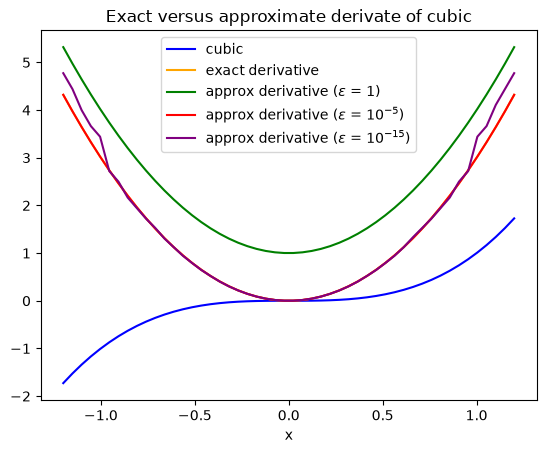

In [94]:
# Your code here. Aim for 8-12 lines.
x = np.linspace(-1.2, 1.2)
plt.plot(x, f(x), label='cubic', color='blue')
plt.plot(x, df_exact(x), label='exact derivative', color='orange')
plt.plot(x, approx_derivative_of(f, 1)(x), label=r'approx derivative ($\epsilon$ = 1)', color='green')
plt.plot(x, approx_derivative_of(f, 10**-5)(x), label=r'approx derivative ($\epsilon$ = $10^{-5}$)', color='red')
plt.plot(x, approx_derivative_of(f, 10**-15)(x), label=r'approx derivative ($\epsilon$ = $10^{-15}$)', color='purple')
plt.xlabel("x")
plt.legend()
plt.title("Exact versus approximate derivate of cubic")
plt.show()

**Run** the code below to download the MNIST dataset of handwritten digits with torchvision and save the first training image of a 2 and of a 3 as PNG files.
The download is about 12 MB (55 MB unpacked) and happens only once.
Later labs need PyTorch and torchvision anyway; if the import fails, install them with `pip install torch torchvision`.

In [95]:
from PIL import ImageOps
from torchvision.datasets import MNIST


def save_mnist_digits(digits=(2, 3), root="data"):
    """Download MNIST and save the first training image of each digit as a 28x28 RGB PNG file."""
    mnist = MNIST(root, train=True, download=True)
    for digit in digits:
        index = (mnist.targets == digit).nonzero()[0].item()  # first image of this digit
        image, label = mnist[index]  # 28x28 grayscale PIL image, white digit on black
        assert label == digit
        image = ImageOps.invert(image).convert("RGB")  # black digit on white, three colour channels
        image.save(f"mnist-digit-{digit}.png")


save_mnist_digits()

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.3 &ndash; Plot a stack of images

**Stack two images and plot them.** Follow these steps:

1. The code above saved a file called [mnist-digit-2.png](mnist-digit-2.png). It contains a 28x28 RGB image (red, green, blue colour channels).
2. Use the **plt.[imread](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imread.html)** function to load the file. Notice that the result of _imread_ is an _ndarray_ object of dtype _np.float32_ with values in $[0, 1]$ and shape (28, 28, 3).
3. Use the **plt.[imshow](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.imshow.html)** function to plot the image. The plot should look like this:

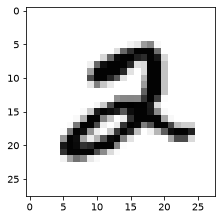
4. The code above also saved a file called [mnist-digit-3.png](mnist-digit-3.png). It contains another 28x28 RGB image.
5. Flip the [mnist-digit-3.png](mnist-digit-3.png) image horizontally using **np.[flip](https://numpy.org/doc/2.1/reference/generated/numpy.flip.html)**
6. Use the **np.[hstack](https://www.numpy.org/devdocs/reference/generated/numpy.hstack.html)** function to create a new image where the digits are side-by-side.
7. Plot the new composite image. It should look like this:

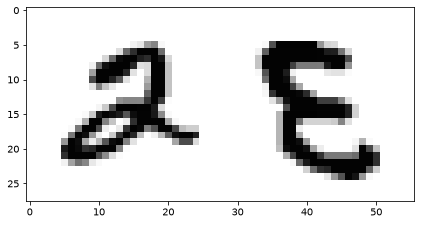

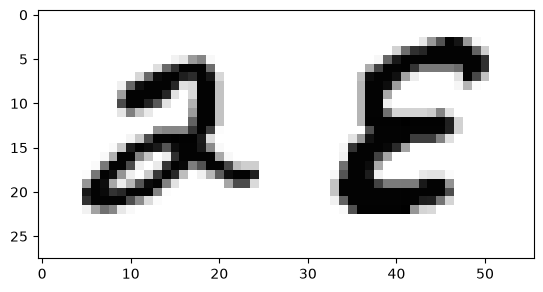

In [96]:
# Your code here. Aim for 4-5 lines.
digit2 = plt.imread("mnist-digit-2.png")
digit3 = np.flip(plt.imread("mnist-digit-3.png"))
stacked = np.hstack((digit2, digit3))
plt.imshow(stacked)

<div style="border-bottom: 3px solid black;"></div>

### Exercise 1.4 &ndash; Plot a normal distribution

The probability density function (PDF) of a normal distribution is defined as follows:
$$
f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\left( -\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^{\!2}\,\right),
$$
where $\mu \in \mathbb{R}$ represents the mean and $\sigma \in \mathbb{R}_+$ the standard deviation.

**Plot a normal distribution.** Follow these steps:
* Implement function `normal_pdf` and plot the PDF.
* Use the **plt.[axvline](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.axvline.html)** to plot the vertical line at `x=mu`.
* Use the **plt.[fill_between](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.fill_between.html)** multiple times to fill the areas according to the [68-95-99.7 rule](https://en.wikipedia.org/wiki/68%E2%80%9395%E2%80%9399.7_rule). <br> Use arguments `where` and `alpha` to select the regions to fill and the opacity, respectively.
* Use the **plt.[scatter](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.scatter.html)** to plot the inflection point. Use arguments `zorder`, `s` and `edgecolors` <br> to set the drawing order, the marker size and the edge color, respectively.
* Use the **plt.[annotate](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.annotate.html)** to annotate the inflection point.
* Use the **plt.[xticks](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.xticks.html)** to set the tick locations and labels.
* Set proper x and y limits, add title and axis labels.

Your plot should look similar to the following:

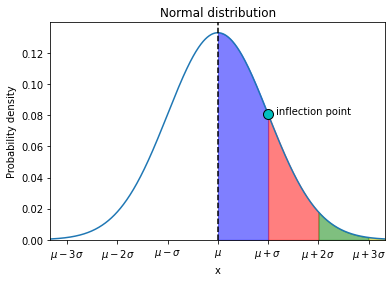

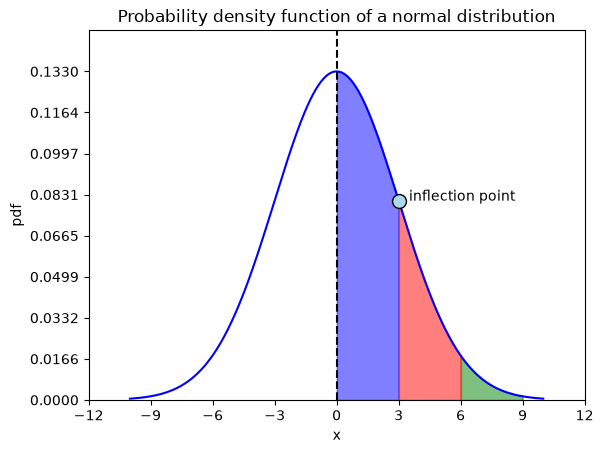

In [103]:
def normal_pdf(x, mu, sigma):
  exp_term = -0.5 * ((x - mu) / sigma) ** 2
  coefficient = 1 / (sigma * np.sqrt(2 * np.pi))
  return coefficient * np.exp(exp_term)

x = np.linspace(-10., 10., num=1000)
mu = 0.
sigma = 3.
pdf = normal_pdf(x, mu, sigma)
inflection_point_x = mu + sigma
inflection_point_y = normal_pdf(inflection_point_x, mu, sigma)

# Your code here. Aim for 15-20 lines.
plt.plot(x, pdf, label='pdf', color='blue')
plt.axvline(x=mu, color='black', linestyle='--')
plt.fill_between(x, pdf, where=(x >= mu) & (x <= inflection_point_x), color='blue', alpha=0.5)
plt.fill_between(x, pdf, where=(x >= inflection_point_x) & (x <= mu + 2*sigma), color='red', alpha=0.5)
plt.fill_between(x, pdf, where=(x >= mu + 2*sigma) & (x <= mu + 3*sigma), color='green', alpha=0.5)
plt.scatter(inflection_point_x, inflection_point_y, zorder=2, s=100, color='lightblue', edgecolors='black')
plt.annotate('inflection point', xy=(inflection_point_x+0.5, inflection_point_y))
plt.xticks(np.arange(mu - 4*sigma, mu + 5*sigma, step=(sigma)))
plt.yticks(np.arange(0, max(pdf) + max(pdf)/8, step=(max(pdf)/8)))
plt.xlim(mu - 4*sigma, mu + 4*sigma)
plt.ylim(0, max(pdf) + max(pdf)/8)
plt.xlabel("x")
plt.ylabel("pdf")
plt.title("Probability density function of a normal distribution")
# plt.grid()
plt.show()

